<a href="https://colab.research.google.com/github/GunaSamhith/ML-labActivity/blob/main/12_6_1_RandomForests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
%matplotlib inline

In [ ]:
rng = np.random.default_rng(7)
spec = {   # mean, std for: weight_g, length_cm, diameter_cm, redness, yellowness, sweetness, firmness
    'Apple':  ([180, 8.0, 7.5, 75, 25, 7.0, 8.0], [25, 0.8, 0.7, 12, 10, 1.0, 0.8]),
    'Banana': ([120, 19.0, 3.5, 5, 90, 8.0, 3.5], [15, 1.5, 0.4, 5, 8, 0.9, 0.8]),
    'Orange': ([200, 8.5, 8.0, 30, 70, 6.5, 6.0], [25, 0.7, 0.7, 10, 10, 1.0, 0.8]),
    'Mango':  ([300, 11.0, 8.0, 45, 70, 8.5, 5.0], [40, 1.2, 0.8, 15, 12, 0.8, 0.9]),
}
cols = ['weight_g', 'length_cm', 'diameter_cm', 'redness', 'yellowness', 'sweetness', 'firmness']
rows = []
for fruit, (mu, sd) in spec.items():
    vals = rng.normal(mu, sd, size=(150, len(cols)))
    d = pd.DataFrame(vals, columns=cols)
    d['fruit'] = fruit
    rows.append(d)
basket = pd.concat(rows, ignore_index=True).round(2)
basket[['redness', 'yellowness']] = basket[['redness', 'yellowness']].clip(0, 100)
basket['sweetness'] = basket['sweetness'].clip(1, 10)
basket['firmness'] = basket['firmness'].clip(1, 10)
basket = basket.sample(frac=1, random_state=1).reset_index(drop=True)
basket.to_csv('fruit_basket.csv', index=False)
print(basket.shape)
print(basket['fruit'].value_counts())
basket.head()

(600, 8)
fruit
Orange    150
Mango     150
Banana    150
Apple     150
Name: count, dtype: int64


,weight_g,length_cm,diameter_cm,redness,yellowness,sweetness,firmness,fruit
0,184.85,7.59,7.49,37.20,77.58,6.28,6.04,Orange
1,181.54,9.12,7.70,22.09,56.60,5.32,5.95,Orange
2,294.74,10.63,6.89,36.36,87.22,8.76,5.66,Mango
3,366.63,11.88,8.67,48.46,72.50,9.02,5.83,Mango
4,118.37,21.90,4.02,4.78,99.67,7.30,3.23,Banana


In [ ]:
X = basket[cols]
y = basket['fruit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41, stratify=y)
print(X_train.shape, X_test.shape)

(420, 7) (180, 7)


In [ ]:
n_trees = 15
trees = []
for i in range(n_trees):
    idx = rng.integers(0, len(X_train), len(X_train))          # random sample with replacement
    t = DecisionTreeClassifier(max_features='sqrt', random_state=i)
    t.fit(X_train.iloc[idx], y_train.iloc[idx])
    trees.append(t)
print(len(trees), 'trees built')

15 trees built


In [ ]:
new_fruit = pd.DataFrame([[190, 8.3, 7.7, 52, 48, 6.8, 6.8]], columns=cols)   # an unknown fruit from the basket
votes = [t.predict(new_fruit)[0] for t in trees]
for i, v in enumerate(votes, 1):
    print(f'Tree-{i}: {v}')

Tree-1: Orange
Tree-2: Orange
Tree-3: Orange
Tree-4: Orange
Tree-5: Orange
Tree-6: Orange
Tree-7: Orange
Tree-8: Orange
Tree-9: Apple
Tree-10: Orange
Tree-11: Orange
Tree-12: Orange
Tree-13: Orange
Tree-14: Orange
Tree-15: Orange


Counter({'Orange': 14, 'Apple': 1})
Final class (majority voting): Orange


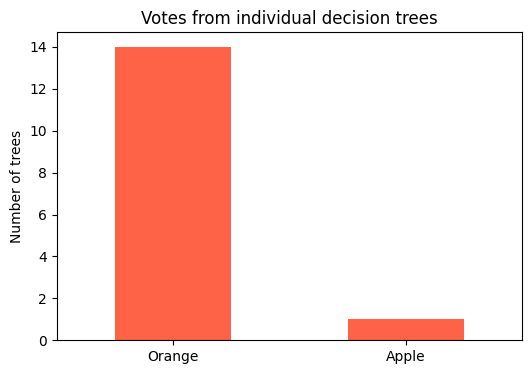

In [ ]:
count = Counter(votes)
print(count)
print('Final class (majority voting):', count.most_common(1)[0][0])

pd.Series(count).sort_values(ascending=False).plot(kind='bar', color='tomato', figsize=(6, 4))
plt.ylabel('Number of trees')
plt.title('Votes from individual decision trees')
plt.xticks(rotation=0)
plt.show()

In [ ]:
model = RandomForestClassifier(n_estimators=n_trees, criterion='entropy', random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Random Forest prediction for the new fruit:', model.predict(new_fruit)[0])
print('Probabilities:', dict(zip(model.classes_, model.predict_proba(new_fruit)[0].round(2).tolist())))

Random Forest prediction for the new fruit: Orange
Probabilities: {'Apple': 0.27, 'Banana': 0.0, 'Mango': 0.07, 'Orange': 0.67}


Accuracy: 0.9889

              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        45
      Banana       1.00      1.00      1.00        45
       Mango       0.98      0.98      0.98        45
      Orange       0.98      0.98      0.98        45

    accuracy                           0.99       180
   macro avg       0.99      0.99      0.99       180
weighted avg       0.99      0.99      0.99       180



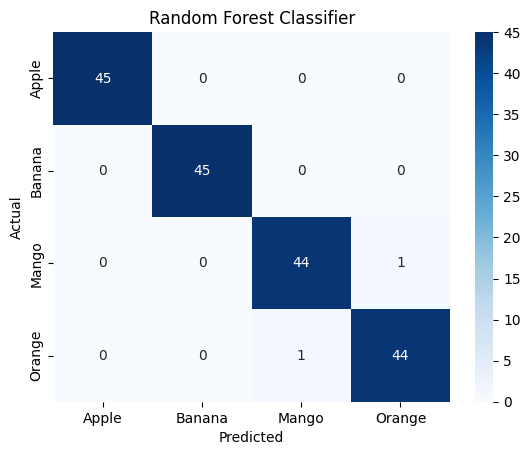

In [ ]:
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

cm = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues').set(title='Random Forest Classifier')
plt.show()

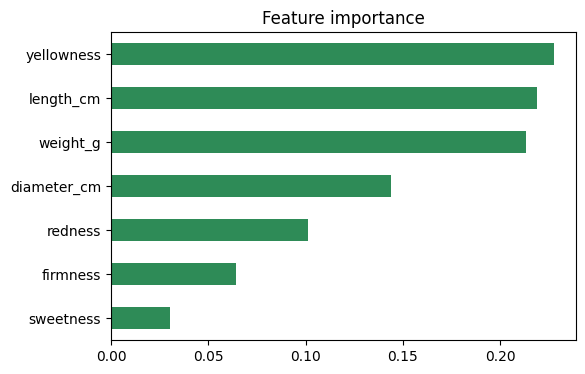

In [ ]:
imp = pd.Series(model.feature_importances_, index=cols).sort_values()
imp.plot(kind='barh', figsize=(6, 4), color='seagreen')
plt.title('Feature importance')
plt.show()

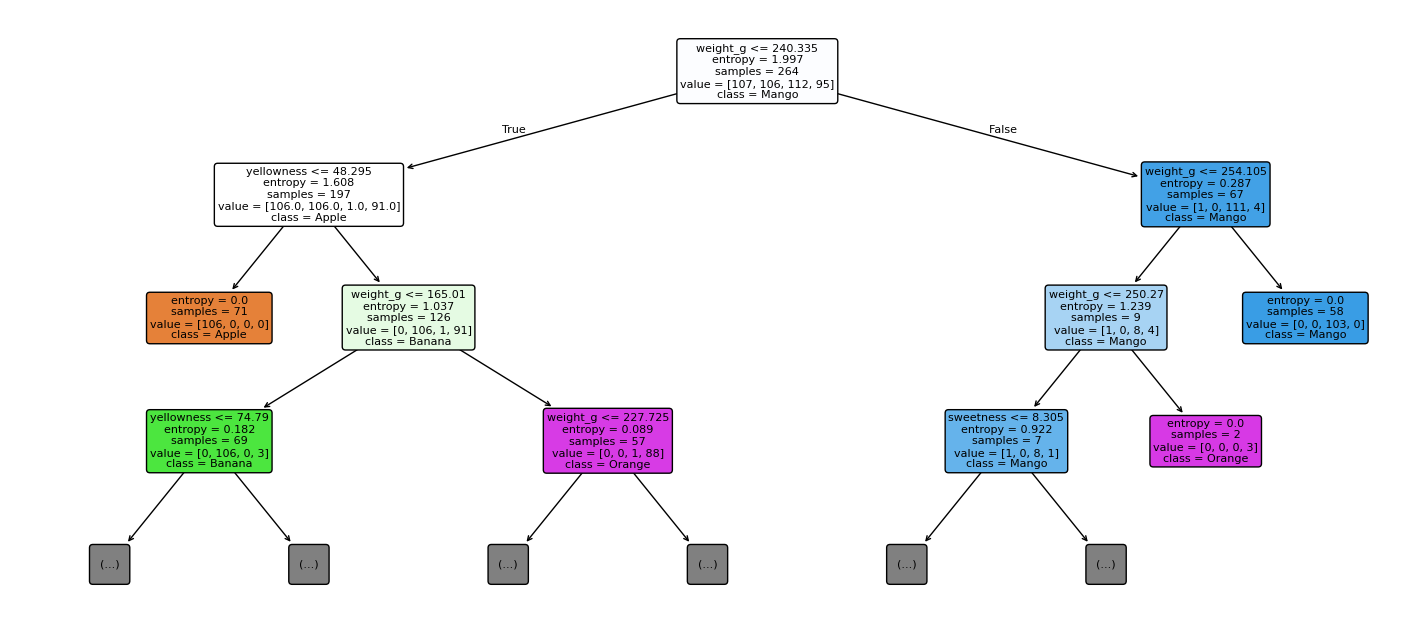

In [ ]:
plt.figure(figsize=(18, 8))
plot_tree(model.estimators_[0], feature_names=cols, class_names=list(model.classes_),
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.show()